# Causal Discovery

In [60]:
!pip install graphviz

## DGP

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from causallearn.search.ConstraintBased.PC import pc
from causallearn.graph.Endpoint import Endpoint
import warnings
warnings.filterwarnings("ignore")

# ====================================
# 1. Generate synthetic causal data
# ====================================
np.random.seed(42)
n = 1000

X1 = np.random.normal(0, 1, n)
X2 = 2*X1 + np.random.normal(0, 1, n)
X3 = 0.5*X1 +1.5*X2 + np.random.normal(0, 1, n)
X4 = X3 + np.random.normal(0, 1, n)
X5 = 1.5*X2 + X4 + np.random.normal(0, 1, n)
data = pd.DataFrame({'X1': X1, 'X2': X2, 'X3': X3, 'X4': X4, 'X5': X5})
X = data.values
names = list(data.columns)
data.head()

,X1,X2,X3,X4,X5
0,0.496714,2.392784,3.162354,1.254547,3.980229
1,-0.138264,0.648105,0.758507,-0.101878,0.839076
2,0.647689,1.355007,1.563936,1.150330,3.200858
3,1.523030,2.399123,4.052238,5.939925,10.011240
4,-0.234153,0.229917,-1.665817,-1.109263,-2.131247


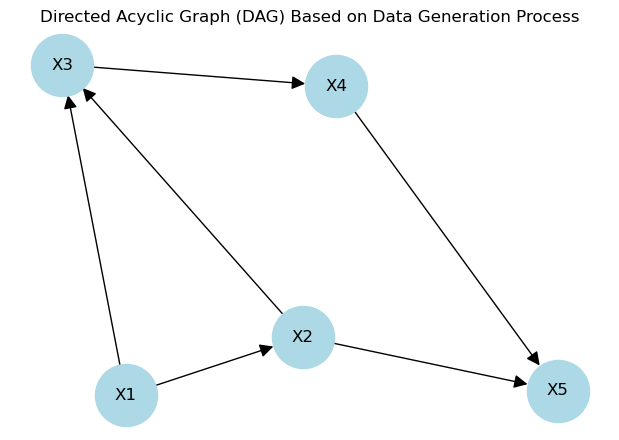

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
# Create a directed graph
dag = nx.DiGraph()
# Define the nodes
nodes = ["X1", "X2", "X3", "X4", "X5"]
dag.add_nodes_from(nodes)
# Define the edges based on the data generation process
edges = [("X1", "X2"), ("X1", "X3"), ("X2", "X3"), ("X3", "X4"), ("X2", "X5"), ("X4", "X5")]
dag.add_edges_from(edges)
# Draw the DAG
plt.figure(figsize=(6, 4))
pos = nx.spring_layout(dag, seed=42)
nx.draw(dag, pos, with_labels=True, node_size=2000, node_color='lightblue', arrowsize=20, font_size=12)
plt.title("Directed Acyclic Graph (DAG) Based on Data Generation Process")
plt.tight_layout()
plt.show()

## (A) Constraint-based methods 
### (A.1) PC (CPDAG)

In [ ]:
import os
import pydot
from IPython.display import Image, display
from causallearn.utils.GraphUtils import GraphUtils

OUTDIR = os.path.expanduser("/Users/Downloads")
os.makedirs(OUTDIR, exist_ok=True)

def render_graph_to_png(graph_obj, filename, labels=None, rankdir="LR"):
    """Convert causal-learn Graph to PNG via pydot, save to OUTDIR, and display."""
    pydot_graph = GraphUtils.to_pydot(graph_obj, labels=labels)
    pydot_graph.set_rankdir(rankdir)
    # Strengthen arrow visibility
    for edge in pydot_graph.get_edges():
        edge.set_dir("forward")
        edge.set_arrowhead("normal")
        edge.set_arrowsize("0.8")
        edge.set_color("#333333")
        edge.set_penwidth("1")
    out_path = os.path.join(OUTDIR, filename)
    pydot_graph.write_png(out_path)
    print(f"[saved] {out_path}")
    display(Image(filename=out_path))  # <-- Display inline

# PC algorithm
from causallearn.search.ConstraintBased.PC import pc
cg = pc(X, alpha=0.05)  # Default Fisher-Z
render_graph_to_png(cg.G, "/Users/causal_graph_pc.png", labels=names)


### (A.2) FCI (PAG)

In [ ]:
from causallearn.search.ConstraintBased.FCI import fci
X=data[['X1','X2','X3','X4','X5']].values
g_pag, edges_fci = fci(X)  
render_graph_to_png(g_pag, "causal_graph_fci.png", labels=names)

In [ ]:
from causallearn.search.ConstraintBased.FCI import fci
X2345=data[['X2','X3','X4','X5']].values

names_fci = ['X2','X3', 'X4', 'X5']
g_pag, edges_fci = fci(X2345) 

def render_fci_graph_to_png(graph_obj, filename, labels=None, rankdir="LR"):
    """Convert causal-learn Graph to PNG via pydot, save to OUTDIR, and display."""
    pydot_graph = GraphUtils.to_pydot(graph_obj, labels=labels)
    pydot_graph.set_rankdir(rankdir)
    # Strengthen arrow visibility
    for edge in pydot_graph.get_edges():
      #  edge.set_dir("forward")
      #  edge.set_arrowhead("normal")
        edge.set_arrowsize("0.8")
        edge.set_color("#333333")
        edge.set_penwidth("1")
    out_path = os.path.join(OUTDIR, filename)
    pydot_graph.write_png(out_path)
    print(f"[saved] {out_path}")
    display(Image(filename=out_path))
    
render_fci_graph_to_png(g_pag, "causal_graph_fci.png", labels=names_fci)

## B) Score-based methods
### B1) GES (CPDAG)

In [ ]:
from causallearn.search.ScoreBased.GES import ges
record_ges = ges(X, score_func='local_score_BIC')
render_graph_to_png(record_ges['G'], "causal_graph_ges.png", labels=names)

## (C) Permutation-based methods
### (C.1) GRaSP

In [ ]:
from causallearn.search.PermutationBased.GRaSP import grasp
G_grasp = grasp(X, score_func='local_score_BIC')
render_graph_to_png(G_grasp, "causal_graph_grasp.png", labels=names)

### (C.2) BOSS

In [ ]:
# Run this code in Python 3.11
from causallearn.search.PermutationBased.BOSS import boss
G_boss = boss(X, score_func='local_score_BIC')
render_graph_to_png(G_boss, "causal_graph_boss.png", labels=names)

## (D) Granger causality (time-series) 


In [42]:
import pandas as pd
# The Coefficients
A = {
    ("X2", "X2", 1):  0.40,
    ("X2", "X5", 1):  0.35,   # X5 -> X2
    ("X5", "X5", 1):  0.45,   # X3 -> X4
    ("X1", "X1", 1):  0.30
}

# Make it a coefficient matrix to display
# Input dictionary: (source, target, lag) -> coefficient
# A 5x10 DataFrame: rows = target, columns = [sources at lag 1] + [sources at lag 2]
vars = ["X1", "X2", "X3", "X4", "X5"]
lags = [1, 2]

columns = [f"{src}(L{lag})" for lag in lags for src in vars]  # X1(L1),...,X5(L1), X1(L2),...,X5(L2)
A_coef = pd.DataFrame(0.0, index=vars, columns=columns)

# Fill the DataFrame from A
for (src, tgt, lag), coef in A.items():
    col = f"{src}(L{lag})"
    A_coef.loc[tgt, col] = coef
A_coef

,X1(L1),X2(L1),X3(L1),X4(L1),X5(L1),X1(L2),X2(L2),X3(L2),X4(L2),X5(L2)
X1,0.3,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0
X2,0.0,0.40,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0
X3,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0
X4,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0
X5,0.0,0.35,0.0,0.0,0.45,0.0,0.0,0.0,0.0,0.0


In [43]:
import numpy as np
import pandas as pd

np.random.seed(123)
T = 1000
p = 5
lags = 2

X = np.zeros((T, p))
X[:lags] = np.random.randn(lags, p) * 0.5

sigma = np.array([0.6, 0.6, 0.7, 0.7, 0.6]) # Noise scales 
name_to_idx = {"X1":0,"X2":1,"X3":2,"X4":3,"X5":4}

for t in range(lags, T):
    noise = np.random.randn(p) * sigma
    Xt = np.zeros(p)
    for (target, source, L), coef in A.items():
        i = name_to_idx[target]
        j = name_to_idx[source]
        Xt[i] += coef * X[t-L, j]
    X[t] = Xt + noise

ts_data = pd.DataFrame(X, columns=["X1","X2","X3","X4","X5"])

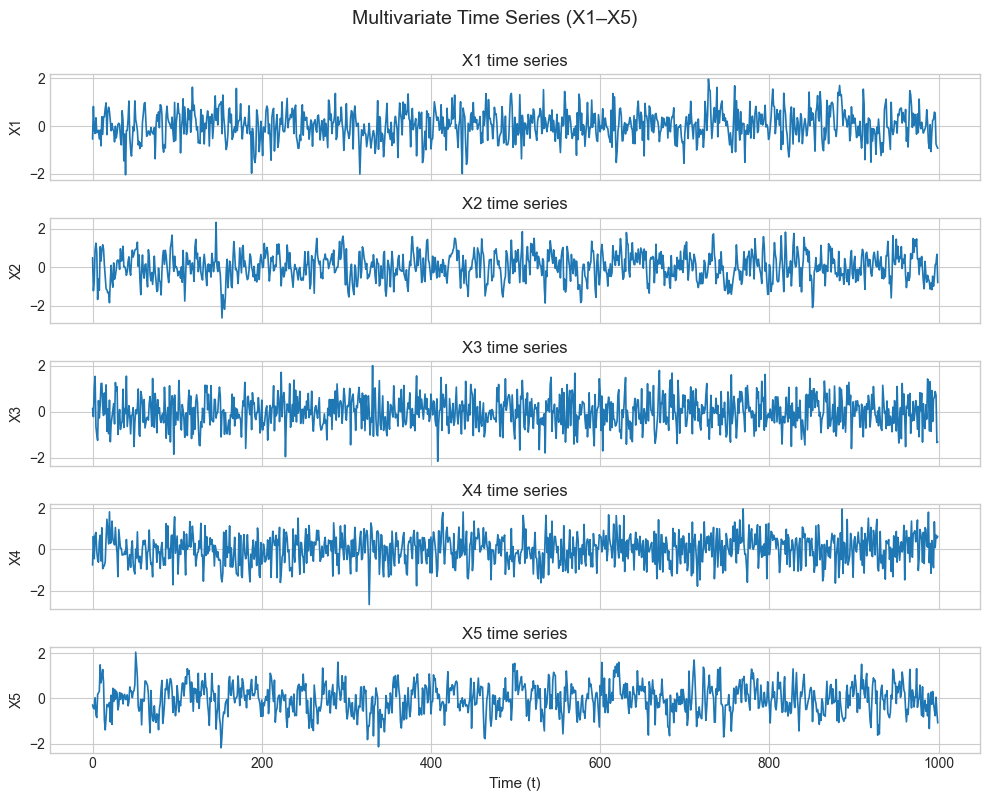

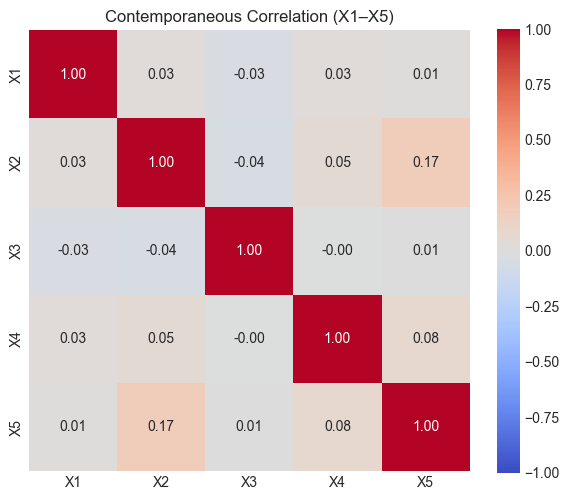

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(10, 8), sharex=True)

for i, col in enumerate(ts_data.columns):
    axes[i].plot(ts_data.index, ts_data[col], color="#1f77b4", linewidth=1.2)
    axes[i].set_title(f"{col} time series", fontsize=12, pad=6)
    axes[i].set_ylabel(col, fontsize=10)

axes[-1].set_xlabel("Time (t)", fontsize=11)
fig.suptitle("Multivariate Time Series (X1–X5)", fontsize=14, y=0.995)
fig.tight_layout()

fig.savefig('time_series_granger.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)  # optional: free memory

# ------------ Optional: correlation heatmap ------------
fig2, ax = plt.subplots(figsize=(6, 5))
corr = ts_data.corr()
sns.heatmap(corr, vmin=-1, vmax=1, annot=True, cmap="coolwarm", square=True, fmt=".2f", ax=ax)
ax.set_title("Contemporaneous Correlation (X1–X5)")
fig2.tight_layout()

fig2.savefig('time_series_granger_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [45]:
import os
from causallearn.search.Granger.Granger import Granger
from IPython.display import Image, display
import pydot

Ggr = Granger()

# Pairwise p-values for 2D series (X2 and X5)
pair = ts_data[["X2", "X5"]].values
pvals = Ggr.granger_test_2d(pair)  # returns [p(X2→X5), p(X5→X2)]

# Robust scalar extraction (handles nested arrays)
def to_float(x):
    arr = np.asarray(x)
    return float(arr.ravel()[0])

p_x2_to_x5 = to_float(pvals[0])
p_x5_to_x2 = to_float(pvals[1])
print(f"[Granger 2D] p(X2→X5)={p_x2_to_x5:.6f}, p(X5→X2)={p_x5_to_x2:.6f}")

[Granger 2D] p(X2→X5)=0.000000, p(X5→X2)=1.000000


In [46]:
# Fit Granger LASSO
G = Granger()
coeff = G.granger_lasso(ts_data.values)   # shape: (p, p * L)
print("coeff shape: (p, p * L):", coeff.shape)

coeff shape: (p, p * L): (5, 10)


In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

names = list(ts_data.columns)           # ["X1","X2","X3","X4","X5"]
p = len(names)
total_cols = coeff.shape[1]
if total_cols % p != 0:
    raise ValueError("Coefficient matrix width is not divisible by number of variables; cannot infer lags.")
L = total_cols // p                  # infer number of lags (here should be 2)

# MultiIndex for columns: (lag, variable)
col_tuples = []
for lag in range(1, L + 1):
    for var in names:
        col_tuples.append((f"lag{lag}", var))
col_index = pd.MultiIndex.from_tuples(col_tuples, names=["lag", "variable"])

# Create a labeled DataFrame
coeff_df = pd.DataFrame(coeff, index=names, columns=col_index).round(1)
print(coeff_df)

lag      lag1                     lag2                    
variable   X1   X2   X3   X4   X5   X1   X2   X3   X4   X5
X1        0.2 -0.0 -0.0 -0.0  0.0  0.0  0.0  0.0  0.0  0.0
X2       -0.0  0.4  0.1 -0.0  0.4  0.0 -0.1  0.0 -0.0  0.0
X3       -0.0 -0.0 -0.0  0.0 -0.1 -0.0 -0.0  0.0 -0.0  0.1
X4        0.0  0.0 -0.0  0.0  0.0  0.0 -0.0  0.0 -0.0  0.0
X5       -0.0 -0.0 -0.0 -0.0  0.4  0.0  0.0 -0.0 -0.0  0.0


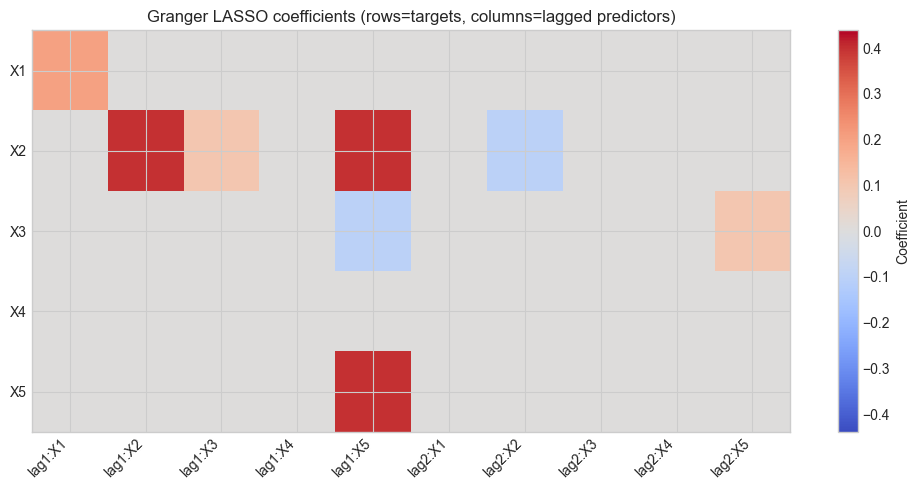

In [48]:
plt.figure(figsize=(10, 5))
flat_cols = [f"{lvl1}:{lvl2}" for (lvl1, lvl2) in coeff_df.columns.to_list()]
coeff_plot = pd.DataFrame(coeff_df.values, index=coeff_df.index, columns=flat_cols)
plt.imshow(coeff_plot, aspect="auto", cmap="coolwarm", vmin=-np.max(np.abs(coeff)), vmax=np.max(np.abs(coeff)))
plt.colorbar(label="Coefficient")
plt.xticks(ticks=np.arange(coeff_plot.shape[1]), labels=flat_cols, rotation=45, ha="right")
plt.yticks(ticks=np.arange(coeff_plot.shape[0]), labels=coeff_plot.index)
plt.title("Granger LASSO coefficients (rows=targets, columns=lagged predictors)")
plt.tight_layout()
plt.savefig('granger_lasso_coefficients.png', dpi=300, bbox_inches='tight')
plt.show()

## (E) Functional Causal Models

In [53]:
#!pip install pygam lingam

### (E.1) ICA-LiNGAM

[saved] /Users/chriskuo/Downloads/causal_graph_ica_lingam_lr.png


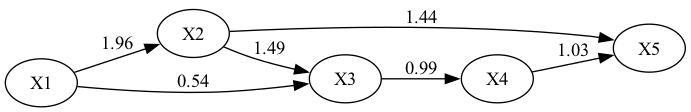

In [50]:
import os
from IPython.display import Image, display
from causallearn.search.FCMBased import lingam
from causallearn.search.FCMBased.lingam.utils import make_dot

OUTDIR = os.path.expanduser("~/Downloads")
os.makedirs(OUTDIR, exist_ok=True)

# 1) Fit ICA-LiNGAM (increase max_iter to avoid convergence issues)
model_ica = lingam.ICALiNGAM(random_state=42, max_iter=5000)
model_ica.fit(data.values)

# 2) Build Graphviz object and force horizontal layout
dot_ica = make_dot(model_ica.adjacency_matrix_, labels=names)
dot_ica.graph_attr.update(rankdir="LR")

# 3) Render to PNG bytes in memory and display inline
png_bytes = dot_ica.pipe(format="png")  # requires Graphviz 'dot' binary
png_path = os.path.join(OUTDIR, "causal_graph_ica_lingam_lr.png")
with open(png_path, "wb") as f:
    f.write(png_bytes)

print(f"[saved] {png_path}")
display(Image(filename=png_path))

### (E.2) VAR-LiNGAM 

In [51]:
from causallearn.search.FCMBased import lingam
model_var = lingam.VARLiNGAM(lags=1)
model_var.fit(ts_data)

In [52]:
np.round(model_var.adjacency_matrices_,1)

array([[[ 0. ,  0. ,  0. ,  0. ,  0. ],
        [ 0. ,  0. ,  0. ,  0. ,  0. ],
        [ 0. ,  0. ,  0. ,  0. ,  0. ],
        [ 0. ,  0. ,  0. ,  0. ,  0. ],
        [ 0. ,  0. ,  0. ,  0. ,  0. ]],

       [[ 0.3, -0. , -0. , -0. ,  0. ],
        [-0. ,  0.4,  0. , -0. ,  0.4],
        [-0. ,  0. , -0.1,  0. , -0.1],
        [ 0. ,  0. , -0. ,  0. ,  0. ],
        [-0. , -0. , -0. , -0. ,  0.5]]])